# 🫁 Clasificación de Neumonía en Radiografías de Tórax
## Ejercicio de Semana Santa - Redes Neuronales Convolucionales (CNN)

---

## 📋 Contexto del Ejercicio

  
**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)  
**Autor del dataset:** Paul Timothy Mooney  

---

## 🎯 Objetivo

Entrenar una Red Neuronal Convolucional (CNN) para **clasificar imágenes de radiografías de tórax** entre dos categorías:
- **NORMAL**: Pulmón sano
- **PNEUMONIA**: Pulmón con neumonía

---

## 📐 Paralelismo con perrosygatos.ipynb

| Elemento | perrosygatos.ipynb | Este Notebook |
|---|---|---|
| Clases | Perros vs Gatos | NORMAL vs PNEUMONIA |
| Task | Clasificación Binaria | Clasificación Binaria |
| Arquitectura | CNN con ResNet blocks | CNN con ResNet blocks |
| split_data | 90% train / 5% val / 5% test | Usa estructura de carpetas original de Kaggle |
| ImageDataGenerator | ✅ | ✅ con Data Augmentation |
| Métricas | Accuracy/Loss | Accuracy/Loss + AUC |

---

# 📦 PASO 1: Importaciones

## ¿Por qué estas librerías?

- **os / shutil**: Para manipular archivos y directorios del dataset
- **numpy**: Operaciones numéricas sobre arrays (imágenes en memoria)
- **tensorflow / keras**: Framework principal para construir y entrenar la CNN
- **matplotlib / plotly**: Visualización de imágenes y métricas de entrenamiento
- **sklearn**: Métricas adicionales como matriz de confusión
- **PIL**: Procesamiento adicional de imágenes

## ¿Qué es Keras?
Keras es la **API de alto nivel** de TensorFlow que nos permite construir redes neuronales de forma modular. Los bloques que usamos son:
- `Conv2D`: Capas convolucionales
- `MaxPooling2D`: Reducción espacial
- `Dense`: Capas totalmente conectadas
- `BatchNormalization`: Normalización por lotes para estabilidad

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from shutil import copyfile
from tensorflow.keras.layers import (
    Conv2D, Add, MaxPooling2D, Dense, BatchNormalization,
    Input, GlobalAveragePooling2D, Dropout, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {tf.keras.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
Keras version: 3.13.2
GPU disponible: False


# 📂 PASO 2: Configuración de Rutas del Dataset

## Estructura del Dataset de Kaggle

El dataset **Chest X-Ray Pneumonia** de Kaggle viene **pre-dividido** en tres conjuntos:  
  
```
chest_xray/
├── train/
│   ├── NORMAL/        # ~1,341 imágenes
│   └── PNEUMONIA/     # ~3,875 imágenes
├── val/
│   ├── NORMAL/        # 8 imágenes
│   └── PNEUMONIA/     # 8 imágenes
└── test/
    ├── NORMAL/        # 234 imágenes
    └── PNEUMONIA/     # 390 imágenes
```

## 🔑 Diferencia vs perrosygatos.ipynb

En el notebook de referencia, la función `split_data()` **crea la partición manualmente** (90% train, 5% val, 5% test) porque el dataset original de Katze-Hund no tenía una división predefinida.  
  
En este caso, **el dataset ya viene particionado por Kaggle**, así que:
1. Usamos la estructura existente.
2. NO necesitamos `split_data()` (aunque se documenta su equivalente).
3. Sí necesitamos **crear una partición de validación más robusta** ya que la carpeta `val/` original solo tiene 16 imágenes.

## 📌 Instrucciones para descargar el dataset

1. Ir a: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
2. Descargar y descomprimir en una carpeta llamada `chest_xray/` dentro de `Pneumonia_EasterWeek/`
3. Si usas Kaggle API: `kaggle datasets download paultimothymooney/chest-xray-pneumonia`

In [6]:
# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

# Directorio base donde está el dataset (ajusta según tu ruta)
BASE_DIR = os.path.join(os.getcwd(), 'chest_xray')

# Si el dataset está en una carpeta diferente, especifícala aquí:
# BASE_DIR = r'C:\ruta\a\chest_xray'

# Rutas de entrenamiento, validación y test
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# Nombres de clases (igual que class_names en perrosygatos.ipynb)
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Verificar que las carpetas existen
for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(directory):
        print(f'✅ Existe: {directory}')
    else:
        print(f'❌ NO EXISTE: {directory}')
        print('   → Asegúrate de descargar el dataset y descomprimirlo aquí.')

✅ Existe: c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\train
✅ Existe: c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\val
✅ Existe: c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\test


# 📊 PASO 3: Análisis Exploratorio de Datos (EDA)

## ¿Qué hacemos aquí?

Antes de entrenar cualquier modelo, es fundamental entender los datos:
1. **Distribución de clases**: ¿Están balanceadas?
2. **Visualizar imágenes**: ¿Cómo se ven las radiografías?
3. **Verificar calidad**: ¿Para corruptos o vacíos?

## ⚠️ Desbalance de Clases

Un problema crítico en el dataset original es el **desbalance de clases**:  
- PNEUMONIA: ~3,875 imágenes de entrenamiento
- NORMAL: ~1,341 imágenes de entrenamiento  
  
Este desbalance (~3:1) puede hacer que el modelo se **sesgue hacia PNEUMONIA**. Lo abordaremos con:
- `class_weight` durante el entrenamiento
- Data Augmentation en la clase minoritaria

In [ ]:
# ============================================================
# CONTEO DE IMÁGENES
# ============================================================

def count_images(base_dir, class_names):
    """
    Cuenta las imágenes en cada subdirectorio de clase.
    
    Argumentos:
    -----------
    base_dir : str
        Directorio raíz (train, val o test)
    class_names : list
        Lista con los nombres de las clases
    
    Retorna:
    ---------
    dict: {clase: número de imágenes}
    """
    counts = {}
    for cls in class_names:
        path = os.path.join(base_dir, cls)
        if os.path.exists(path):
            # Filtrar solo archivos de imagen
            images = [f for f in os.listdir(path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[cls] = len(images)
        else:
            counts[cls] = 0
    return counts

# Contar imágenes por split
train_counts = count_images(TRAIN_DIR, CLASS_NAMES)
val_counts   = count_images(VAL_DIR,   CLASS_NAMES)
test_counts  = count_images(TEST_DIR,  CLASS_NAMES)

# Totales
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
total_all   = total_train + total_val + total_test

print('='*50)
print('DISTRIBUCIÓN DEL DATASET')
print('='*50)
print(f'\n📁 ENTRENAMIENTO ({total_train} imágenes | {(total_train/total_all)*100:.1f}%)')
for cls, cnt in train_counts.items():
    print(f'   {cls}: {cnt} ({cnt/total_train*100:.1f}%)')

print(f'\n📁 VALIDACIÓN ({total_val} imágenes | {(total_val/total_all)*100:.1f}%)')
for cls, cnt in val_counts.items():
    print(f'   {cls}: {cnt} ({cnt/total_val*100:.1f}%)' if total_val > 0 else f'   {cls}: {cnt}')

print(f'\n📁 TEST ({total_test} imágenes | {(total_test/total_all)*100:.1f}%)')
for cls, cnt in test_counts.items():
    print(f'   {cls}: {cnt} ({cnt/total_test*100:.1f}%)')

print(f'\n📊 TOTAL: {total_all} imágenes')

# Gráfico de pie (igual que perrosygatos.ipynb)
fig = px.pie(
    names=CLASS_NAMES,
    values=[train_counts.get(c, 0) for c in CLASS_NAMES],
    title='Distribución de clases - Entrenamiento',
    color_discrete_sequence=['#2E86AB', '#E84855']
)
fig.show()

# Calcular class weights para compensar desbalance
n_normal    = train_counts.get('NORMAL', 1)
n_pneumonia = train_counts.get('PNEUMONIA', 1)
total_train_imgs = n_normal + n_pneumonia

class_weight = {
    0: total_train_imgs / (2 * n_normal),    # NORMAL
    1: total_train_imgs / (2 * n_pneumonia)  # PNEUMONIA
}
print(f'\n⚖️  Class Weights (para compensar desbalance):')
print(f'   NORMAL    (clase 0): {class_weight[0]:.3f}')
print(f'   PNEUMONIA (clase 1): {class_weight[1]:.3f}')

DISTRIBUCIÓN DEL DATASET

📁 ENTRENAMIENTO (5216 imágenes | 89.1%)
   NORMAL: 1341 (25.7%)
   PNEUMONIA: 3875 (74.3%)

📁 VALIDACIÓN (16 imágenes | 0.3%)
   NORMAL: 8 (50.0%)
   PNEUMONIA: 8 (50.0%)

📁 TEST (624 imágenes | 10.7%)
   NORMAL: 234 (37.5%)
   PNEUMONIA: 390 (62.5%)

📊 TOTAL: 5856 imágenes



⚖️  Class Weights (para compensar desbalance):
   NORMAL    (clase 0): 1.945
   PNEUMONIA (clase 1): 0.673


# 🖼️ PASO 4: Visualización de Imágenes del Dataset

## Función plot_sample_images

Similar a la función `plot_data()` del notebook de perrosygatos, esta función:
1. Lee imágenes de las carpetas del dataset
2. Las muestra en una cuadrícula con su etiqueta

**Diferencia clave**: Aquí leemos directamente del disco (no del generador) para poder visualizar antes de crear los generadores.

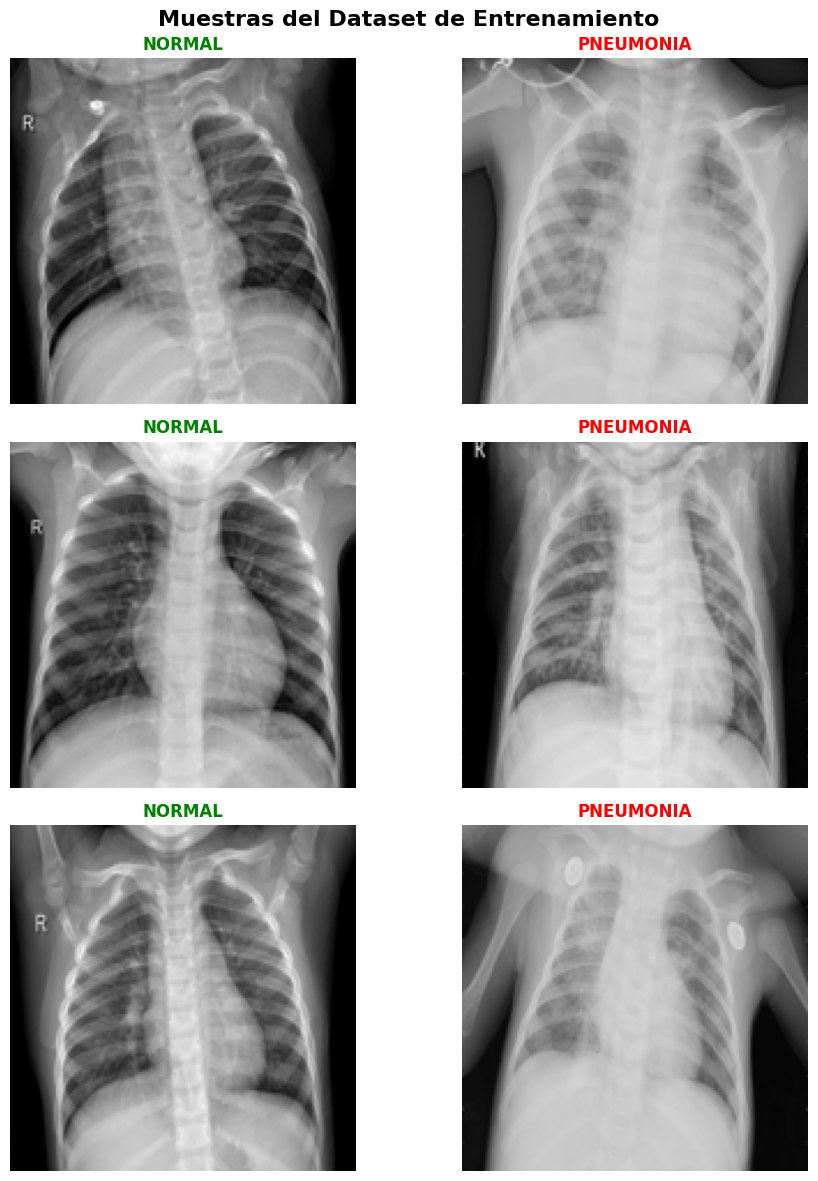

In [8]:
def plot_sample_images(base_dir, class_names, n_per_class=3, img_size=(150, 150)):
    """
    Muestra imágenes de muestra de cada clase.
    Equivalente a plot_data() en perrosygatos.ipynb.
    
    Parámetros:
    -----------
    base_dir : str
        Directorio raíz del split (e.g., TRAIN_DIR)
    class_names : list
        Lista de nombres de clase
    n_per_class : int
        Número de imágenes a mostrar por clase
    img_size : tuple
        Tamaño para redimensionar (ancho, alto)
    """
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_per_class, n_classes, figsize=(5*n_classes, 4*n_per_class))
    fig.suptitle('Muestras del Dataset de Entrenamiento', fontsize=16, fontweight='bold')
    
    for col, cls in enumerate(class_names):
        cls_path = os.path.join(base_dir, cls)
        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        sample = random.sample(images, min(n_per_class, len(images)))
        
        for row, img_name in enumerate(sample):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path).convert('RGB').resize(img_size)
            
            ax = axes[row, col] if n_per_class > 1 else axes[col]
            ax.imshow(img, cmap='gray')
            ax.set_title(f'{cls}', fontsize=12,
                         color='green' if cls == 'NORMAL' else 'red',
                         fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar muestras de entrenamiento
plot_sample_images(TRAIN_DIR, CLASS_NAMES, n_per_class=3)

# 📦 PASO 5: Gestión de la Partición de Datos

## La función split_data de perrosygatos.ipynb

En el notebook original, la función `split_data()` tomaba un directorio de imágenes y lo dividía en:
- **90%** → Entrenamiento
- **5%** → Validación  
- **5%** → Test

```python
# En perrosygatos.ipynb:
split_data(CAT_DIR, 'cats-vs-dogs/training/cats', 
           'cats-vs-dogs/validation/cats', 
           'cats-vs-dogs/test/cats', INCLUDE_TEST, 0.9)
```

## Adaptación para este dataset

El dataset de Kaggle **ya viene pre-dividido**, PERO tiene un problema:
- La carpeta `val/` tiene solo **16 imágenes** (8 por clase), insuficiente para validación.

**Solución**: Creamos una función `create_balanced_val()` que extrae un subconjunto de `train/` para crear una validación más robusta.

### ¿Por qué importa la validación?
La validación nos dice **si el modelo está generalizando o memorizando** (overfitting). Con solo 16 imágenes, las métricas de validación serían inestables.

In [9]:
# ============================================================
# FUNCIÓN split_data (equivalente al notebook de referencia)
# ============================================================

def split_data_from_train(train_dir, new_val_dir, class_names,
                           val_split=0.1, seed=42):
    """
    Adapta la lógica de split_data() de perrosygatos.ipynb:
    - Lee archivos del directorio de entrenamiento
    - Descarta archivos vacíos o corruptos
    - Mezcla aleatoriamente
    - Separa un % para validación
    - Copia imágenes a las carpetas correspondientes
    
    Parámetros:
    -----------
    train_dir : str
        Directorio de entrenamiento original del dataset
    new_val_dir : str
        Directorio destino para la nueva validación
    class_names : list
        Nombres de las clases
    val_split : float
        Fracción de datos a usar para validación (default 10%)
    seed : int
        Semilla para reproducibilidad
    
    Nota: Esta función MUEVE imágenes de train/ a val_new/
           Para mantener train intacto, hace COPIAS.
    """
    random.seed(seed)
    
    for cls in class_names:
        src_dir = os.path.join(train_dir, cls)
        dst_dir = os.path.join(new_val_dir, cls)
        os.makedirs(dst_dir, exist_ok=True)
        
        # Obtener todos los archivos no vacíos (como en perrosygatos)
        files = []
        for f in os.listdir(src_dir):
            filepath = os.path.join(src_dir, f)
            # Verificar que el archivo no está vacío (getsize > 0)
            if os.path.getsize(filepath) > 0 and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                files.append(f)
        
        # Mezclar aleatoriamente (random.sample como en perrosygatos)
        shuffled = random.sample(files, len(files))
        
        # Calcular split
        n_val = int(val_split * len(shuffled))
        val_files = shuffled[:n_val]
        
        print(f'  Clase {cls}: {len(files)} total → {n_val} para validación')
        
        # Copiar archivos de validación
        for fname in val_files:
            copyfile(
                os.path.join(src_dir, fname),
                os.path.join(dst_dir, fname)
            )

# Directorio para la nueva validación
NEW_VAL_DIR = os.path.join(os.path.dirname(BASE_DIR), 'chest_xray_new_val')

# Solo crear si no existe
if not os.path.exists(NEW_VAL_DIR):
    print('Creando partición de validación robusta (10% de train)...')
    split_data_from_train(TRAIN_DIR, NEW_VAL_DIR, CLASS_NAMES, val_split=0.10)
    print('✅ Partición creada exitosamente!')
else:
    print('✅ Partición de validación ya existe, usando la existente.')

# Usar la nueva validación
EFFECTIVE_VAL_DIR = NEW_VAL_DIR

# Verificar conteos finales (igual que en perrosygatos.ipynb)
train_counts_final = count_images(TRAIN_DIR, CLASS_NAMES)
val_counts_final   = count_images(EFFECTIVE_VAL_DIR, CLASS_NAMES)
test_counts_final  = count_images(TEST_DIR, CLASS_NAMES)

print('\n' + '='*50)
print('DISTRIBUCIÓN FINAL DEL DATASET')
print('='*50)
print(f"Train NORMAL:     {train_counts_final.get('NORMAL', 0)}  imágenes")
print(f"Train PNEUMONIA:  {train_counts_final.get('PNEUMONIA', 0)} imágenes")
print(f"Total Training:   {sum(train_counts_final.values())} imágenes")
print()
print(f"Val NORMAL:       {val_counts_final.get('NORMAL', 0)} imágenes")
print(f"Val PNEUMONIA:    {val_counts_final.get('PNEUMONIA', 0)} imágenes")
print(f"Total Validation: {sum(val_counts_final.values())} imágenes")
print()
print(f"Test NORMAL:      {test_counts_final.get('NORMAL', 0)} imágenes")
print(f"Test PNEUMONIA:   {test_counts_final.get('PNEUMONIA', 0)} imágenes")
print(f"Total Test:       {sum(test_counts_final.values())} imágenes")

Creando partición de validación robusta (10% de train)...
  Clase NORMAL: 1341 total → 134 para validación
  Clase PNEUMONIA: 3875 total → 387 para validación
✅ Partición creada exitosamente!

DISTRIBUCIÓN FINAL DEL DATASET
Train NORMAL:     1341  imágenes
Train PNEUMONIA:  3875 imágenes
Total Training:   5216 imágenes

Val NORMAL:       134 imágenes
Val PNEUMONIA:    387 imágenes
Total Validation: 521 imágenes

Test NORMAL:      234 imágenes
Test PNEUMONIA:   390 imágenes
Total Test:       624 imágenes


# 🔄 PASO 6: Generadores de Datos (ImageDataGenerator)

## ¿Qué son los generadores?

Los generadores de datos en Keras **cargan imágenes del disco en lotes (batches)** durante el entrenamiento, evitando cargar todo el dataset en memoria RAM.

## 🎛️ Parámetros clave

### rescale=1./255
Las imágenes tienen píxeles en rango [0, 255]. Las dividimos entre 255 para obtener valores en [0, 1].
- **Por qué**: Las redes neuronales funcionan mejor con entradas pequeñas; evita gradientes explosivos.

### Data Augmentation (solo en entrenamiento)
Técnicas que **crean variaciones artificiales** de las imágenes existentes:
- `rotation_range=20`: Rotar hasta 20°
- `width_shift_range=0.2`: Desplazar horizontalmente hasta 20%
- `horizontal_flip=True`: Voltear horizontalmente
- `zoom_range=0.2`: Hacer zoom hasta 20%

**¿Por qué usar augmentation?**  
Como el dataset está desbalanceado y puede ser pequeño, el augmentation:
1. Aumenta artificialmente el tamaño del dataset
2. Ayuda al modelo a ser **más robusto a variaciones**
3. Reduce el **overfitting**

## Diferencia con perrosygatos.ipynb

En el notebook original solo se usó `rescale=1./255` sin augmentation. Aquí añadimos augmentation porque:
- El dataset médico es más pequeño
- Las variaciones en radiografías son realistas (distintos ángulos, exposiciones)
- El desbalance requiere técnicas adicionales

In [10]:
# ============================================================
# PARÁMETROS GLOBALES (como en perrosygatos.ipynb)
# ============================================================

IMG_SIZE   = (150, 150)  # Misma dimensión que en perrosygatos
BATCH_SIZE = 32          # Tamaño de lote

# ============================================================
# GENERADORES DE DATOS
# ============================================================

# Generador de ENTRENAMIENTO con Data Augmentation
# En perrosygatos.ipynb: train_gen = ImageDataGenerator(rescale=1./255)
# Aquí lo extendemos con augmentation para mejorar la generalización
train_gen = ImageDataGenerator(
    rescale=1./255,           # Normalización: píxeles en [0,1]
    rotation_range=20,        # Rotación aleatoria ±20°
    width_shift_range=0.2,    # Desplazamiento horizontal ±20%
    height_shift_range=0.2,   # Desplazamiento vertical ±20%
    horizontal_flip=True,     # Volteo horizontal aleatorio
    zoom_range=0.2,           # Zoom aleatorio ±20%
    shear_range=0.1,          # Transformación de cizalla
    fill_mode='nearest'       # Relleno de píxeles al bordear
)

# Generador de VALIDACIÓN: solo rescale, sin augmentation
# (La augmentation solo se aplica al entrenamiento)
validation_gen = ImageDataGenerator(rescale=1./255)

# Generador de TEST: solo rescale
test_gen = ImageDataGenerator(rescale=1./255)

# ============================================================
# CREAR ITERADORES DE DATOS
# ============================================================

# Iterador de entrenamiento
# class_mode='binary' porque tenemos 2 clases (0=NORMAL, 1=PNEUMONIA)
train_generator = train_gen.flow_from_directory(
    TRAIN_DIR,                   # Directorio con subcarpetas por clase
    target_size=IMG_SIZE,        # Redimensionar todas las imágenes
    batch_size=BATCH_SIZE,       # Lotes de 32 imágenes
    class_mode='binary',         # Clasificación binaria
    shuffle=True,                # Mezclar en cada época
    seed=42
)

# Iterador de validación
validation_generator = validation_gen.flow_from_directory(
    EFFECTIVE_VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Iterador de test
test_generator = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False               # No mezclar para eval correcta
)

print(f'\n🗂️  Índices de clase: {train_generator.class_indices}')
print(f'   0 = NORMAL, 1 = PNEUMONIA (clasificación binaria con sigmoide)')

Found 5216 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

🗂️  Índices de clase: {'NORMAL': 0, 'PNEUMONIA': 1}
   0 = NORMAL, 1 = PNEUMONIA (clasificación binaria con sigmoide)


## 🔍 Visualización del Data Augmentation

Es importante **verificar** que el augmentation produce imágenes razonables y no distorsiones exageradas.

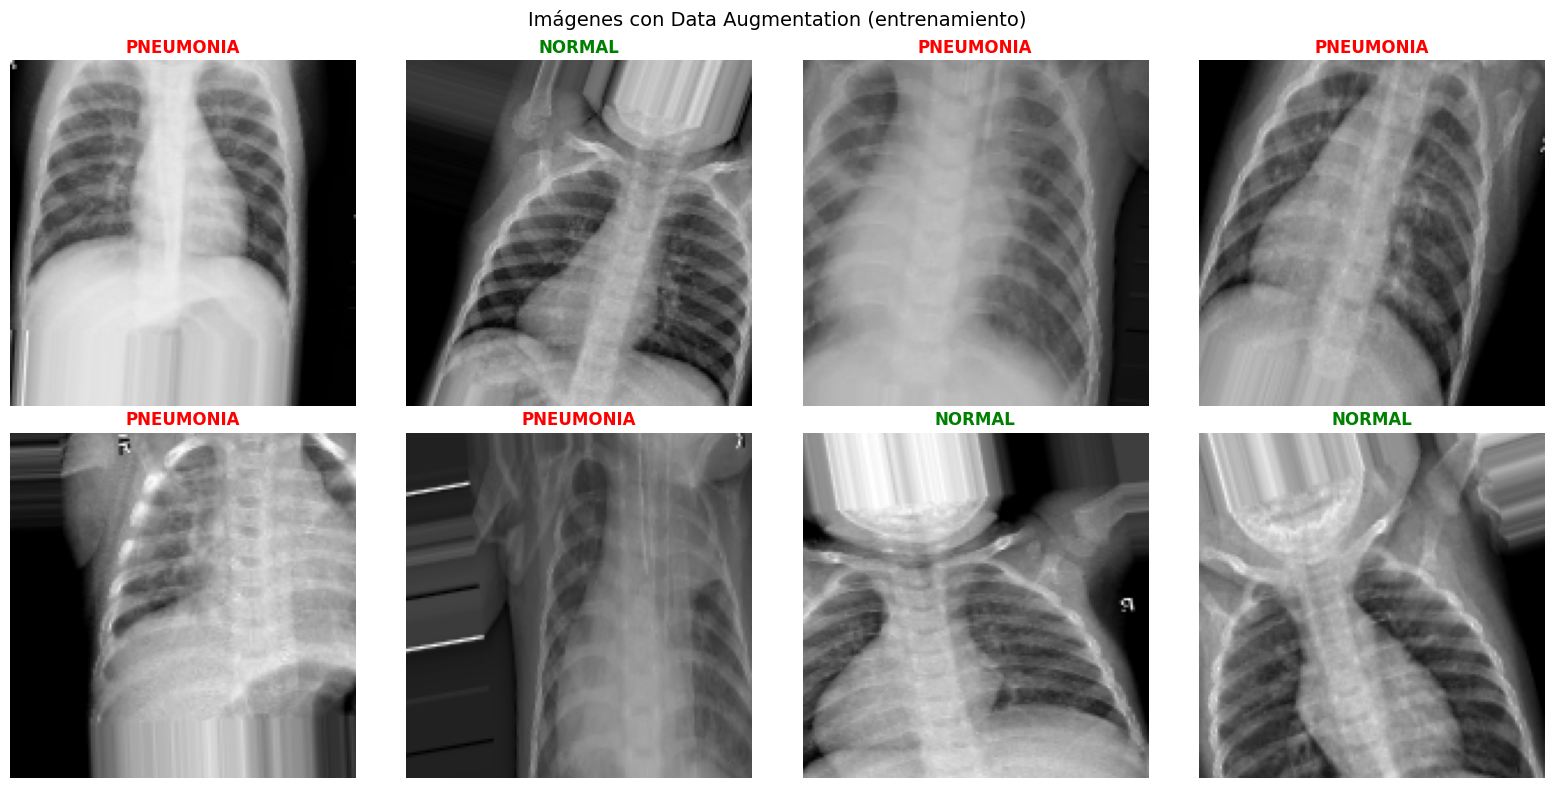

In [11]:
# Visualizar efecto del augmentation
def plot_augmented_images(generator, class_names, n_images=8):
    """
    Equivalente a plot_data() de perrosygatos.ipynb pero sobre
    el iterador del generador con augmentation aplicado.
    """
    images, labels = next(generator)
    labels = labels.astype('int32')
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(min(n_images, len(images))):
        axes[i].imshow(images[i])  # Ya normalizado [0,1]
        cls_name = class_names[labels[i]] if labels[i] < len(class_names) else str(labels[i])
        color = 'green' if cls_name == 'NORMAL' else 'red'
        axes[i].set_title(cls_name, color=color, fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle('Imágenes con Data Augmentation (entrenamiento)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_augmented_images(train_generator, CLASS_NAMES, n_images=8)

# 🧠 PASO 7: Arquitectura de la Red Neuronal Convolucional

## Fundamento Teórico

### ¿Qué es una CNN?
Una **Red Neuronal Convolucional** (Convolutional Neural Network) está diseñada para procesar datos con estructura de cuadrícula, como imágenes. Aprende automáticamente **filtros** que detectan características visuales.

### ¿Cómo funciona una capa Conv2D?
```
Entrada (150x150x3)  →  Filtro 3x3  →  Feature Map
```
- **Filtro**: Una pequeña matriz que "escanea" la imagen
- **Feature Map**: El resultado de aplicar el filtro
- Se aprenden múltiples filtros (e.g., 32 filtros → 32 feature maps)

### ¿Por qué BatchNormalization?
Normaliza las activaciones entre capas:
- Estabiliza el entrenamiento
- Permite tasas de aprendizaje más altas
- Actúa como regularizador

### ¿Por qué MaxPooling?
Reduce el tamaño espacial (downsampling):
- Reduce el costo computacional
- Proporciona invarianza a pequeñas traslaciones

### Bloque Residual (de perrosygatos.ipynb)
En el notebook de referencia se usaron **bloques residuales** (ResNet-style):  
```
x  →  Conv  →  BN  →  ReLU  →  Conv  →  BN  →  (+) x_original  →  ReLU
```
Esto crea **conexiones de salto** que facilitan el flujo del gradiente.

## 📐 Arquitectura de este modelo

```
Input (150, 150, 3)
    ↓
Conv2D(32, 3x3) + BN + ReLU
    ↓
MaxPool(2x2)  →  (75, 75, 32)
    ↓
ResBlock(64)
    ↓
MaxPool(2x2)  →  (37, 37, 64)
    ↓
ResBlock(128)
    ↓
MaxPool(2x2)  →  (18, 18, 128)
    ↓
GlobalAveragePooling2D  →  (128,)
    ↓
Dense(256) + Dropout(0.5)
    ↓
Dense(1, sigmoid)  →  P(PNEUMONIA)
```

### Función de activación sigmoide en la salida
$$\sigma(x) = \frac{1}{1+e^{-x}} \in (0, 1)$$

Interpreta: P(PNEUMONIA | radiografía). Si > 0.5 → PNEUMONIA, si ≤ 0.5 → NORMAL.

In [12]:
# ============================================================
# BLOQUE RESIDUAL (igual que en perrosygatos.ipynb)
# ============================================================

def residual_block(x, filters, kernel_size=3):
    """
    Bloque residual estilo ResNet.
    Tomado de la arquitectura de perrosygatos.ipynb y adaptado.
    
    Estructura:
        x → Conv2D → BN → ReLU → Conv2D → BN → (+x) → ReLU
    
    El Add()(x_original, x_transformado) crea la 'conexión de salto'
    que permite que el gradiente fluya sin degradarse.
    
    Parámetros:
    -----------
    x : Tensor
        Tensor de entrada
    filters : int
        Número de filtros
    kernel_size : int
        Tamaño del kernel (default 3x3)
    
    Retorna:
    ---------
    Tensor de salida con misma dimensión espacial, filters canales
    """
    shortcut = x
    
    # Primera convolución
    x = Conv2D(filters, kernel_size, padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    # Segunda convolución
    x = Conv2D(filters, kernel_size, padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    
    # Ajustar dimensión del shortcut si es necesario
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    
    # Conexión de salto (Add en perrosygatos.ipynb)
    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    
    return x

# ============================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================

def build_pneumonia_cnn(input_shape=(150, 150, 3)):
    """
    Construye el modelo CNN para clasificación de neumonía.
    Basado en la misma filosofía de perrosygatos.ipynb:
    Conv2D + BatchNorm + ResBlocks + Dense
    
    Parámetros:
    -----------
    input_shape : tuple
        Dimensiones de entrada (alto, ancho, canales)
    
    Retorna:
    ---------
    model : tf.keras.Model
        Modelo compilado
    """
    # Capa de entrada
    inputs = Input(shape=input_shape, name='input_radiografia')
    
    # ── Bloque 1: Extracción de características básicas ──
    x = Conv2D(32, (3, 3), padding='same', name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = tf.keras.layers.Activation('relu', name='relu1')(x)
    x = MaxPooling2D((2, 2), name='pool1')(x)  # 75x75x32
    
    # ── Bloque 2: Residual 64 filtros ──
    x = residual_block(x, filters=64)
    x = MaxPooling2D((2, 2), name='pool2')(x)  # 37x37x64
    x = Dropout(0.25, name='dropout1')(x)
    
    # ── Bloque 3: Residual 128 filtros ──
    x = residual_block(x, filters=128)
    x = MaxPooling2D((2, 2), name='pool3')(x)  # 18x18x128
    x = Dropout(0.25, name='dropout2')(x)
    
    # ── Bloque 4: Residual 256 filtros ──
    x = residual_block(x, filters=256)
    
    # ── Pooling Global: Colapsar dimensiones espaciales ──
    # GlobalAveragePooling toma el promedio de cada feature map
    # Más robusto que Flatten para imágenes
    x = GlobalAveragePooling2D(name='gap')(x)  # (batch, 256)
    
    # ── Capas Densas Finales ──
    x = Dense(256, activation='relu', name='dense1')(x)
    x = Dropout(0.5, name='dropout3')(x)
    
    # Capa de salida: 1 neurona con sigmoide 
    # = probabilidad de PNEUMONIA
    outputs = Dense(1, activation='sigmoid', name='output_pneumonia')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='PneumoniaCNN')
    return model

# Crear el modelo
model = build_pneumonia_cnn(input_shape=IMG_SIZE + (3,))

# Resumen del modelo
model.summary()

Model: "PneumoniaCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_radiografia   │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 150, 150,  │        896 │ input_radiografi… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 150, 150,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 150, 150,  │          0 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 75, 75,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 75,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 75,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 75, 75,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 75, 75,    │      2,112 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 75, 75,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 37, 37,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 37, 37,    │          0 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 37, 37,    │     73,856 │ dropout1[0][0]  

 Total params: 1,278,017 (4.88 MB)

 Trainable params: 1,275,265 (4.86 MB)

 Non-trainable params: 2,752 (10.75 KB)

# ⚙️ PASO 8: Compilación del Modelo

## Función de pérdida: Binary Crossentropy

Para clasificación binaria, usamos la **entropía cruzada binaria**:

$$L = -\frac{1}{N}\sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$

- $y_i$: Etiqueta real (0=NORMAL, 1=PNEUMONIA)
- $\hat{y}_i$: Predicción del modelo (probabilidad entre 0 y 1)

## Optimizador: Adam

Adam (Adaptive Moment Estimation) es el optimizador estándar:
- Adapta la tasa de aprendizaje para cada parámetro
- Combina las ventajas de AdaGrad y RMSProp
- `learning_rate=0.001` es el valor por defecto usual

## Métricas

- **Accuracy**: Fracción de predicciones correctas
- **AUC**: Área Bajo la Curva ROC (mide discriminación entre clases)
  - AUC = 1.0: Clasificador perfecto
  - AUC = 0.5: Clasificador aleatorio

In [13]:
# ============================================================
# COMPILACIÓN DEL MODELO (como en perrosygatos.ipynb)
# ============================================================

LEARNING_RATE = 0.001

# Optimizer: Adam (igual que en perrosygatos.ipynb)
optimizer = Adam(learning_rate=LEARNING_RATE)

# Compilar el modelo
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',          # Pérdida para 2 clases con sigmoide
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc') # Área bajo la curva ROC
    ]
)

print('✅ Modelo compilado correctamente')
print(f'   Optimizador: Adam (lr={LEARNING_RATE})')
print(f'   Pérdida: binary_crossentropy')
print(f'   Métricas: accuracy, AUC')
print(f'   Parámetros totales: {model.count_params():,}')

✅ Modelo compilado correctamente
   Optimizador: Adam (lr=0.001)
   Pérdida: binary_crossentropy
   Métricas: accuracy, AUC
   Parámetros totales: 1,278,017


# 📞 PASO 9: Callbacks de Entrenamiento

## ¿Qué son los callbacks?

Los **callbacks** son funciones que se llaman en ciertos puntos durante el entrenamiento. En el notebook de perrosygatos se usó `LearningRateScheduler`.

Aquí ampliamos con:

### EarlyStopping
**Detiene el entrenamiento** si la métrica de validación no mejora por `patience` épocas.  
- Evita el overfitting y ahorra tiempo
- `restore_best_weights=True`: Restaura el mejor modelo encontrado

### ReduceLROnPlateau  
**Reduce la tasa de aprendizaje** cuando la pérdida de validación se estanca.
- Factor: nueva_lr = lr × factor
- Similar al `LearningRateScheduler` de perrosygatos pero automático

### LearningRateScheduler (de perrosygatos.ipynb)
Reduce la tasa de aprendizaje cada cierto número de épocas de forma programática.

In [14]:
# ============================================================
# CALLBACKS (ampliando lo de perrosygatos.ipynb)
# ============================================================

# 1. LearningRateScheduler (de perrosygatos.ipynb)
def lr_schedule(epoch, lr):
    """
    Scheduler de tasa de aprendizaje.
    Igual al usado en perrosygatos.ipynb.
    Reduce el LR un 10% cada 5 épocas.
    """
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.9
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule, verbose=1)

# 2. EarlyStopping: Parar si val_loss no mejora en 10 épocas
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 3. ReduceLROnPlateau: Reducir LR si val_loss se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Multiplica LR por 0.5
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [lr_scheduler, early_stopping, reduce_lr]

print('✅ Callbacks configurados:')
print('   - LearningRateScheduler: -10% cada 5 épocas')
print('   - EarlyStopping: patience=10, restora mejores pesos')
print('   - ReduceLROnPlateau: factor=0.5, patience=5')

✅ Callbacks configurados:
   - LearningRateScheduler: -10% cada 5 épocas
   - EarlyStopping: patience=10, restora mejores pesos
   - ReduceLROnPlateau: factor=0.5, patience=5


# 🏋️ PASO 10: Entrenamiento del Modelo

## ¿Qué sucede durante el entrenamiento?

En cada **época** (epoch):
1. El modelo procesa todos los batches de entrenamiento
2. Calcula la pérdida y actualiza los pesos (backpropagation)
3. Evalúa en el conjunto de validación
4. Los callbacks monitoran el progreso

## class_weight para desbalance

El parámetro `class_weight` penaliza más los errores en la clase minoritaria (NORMAL), obligando al modelo a aprender ambas clases equitativamente.

## steps_per_epoch

$$\text{steps\_per\_epoch} = \lceil \frac{N_{train}}{batch\_size} \rceil$$

Número de batches que se procesan por época.

In [15]:
# ============================================================
# ENTRENAMIENTO (model.fit como en perrosygatos.ipynb)
# ============================================================

EPOCHS = 30  # Máximo de épocas (EarlyStopping puede parar antes)

# Calcular steps por época
steps_per_epoch      = np.ceil(sum(train_counts_final.values()) / BATCH_SIZE).astype(int)
validation_steps     = np.ceil(sum(val_counts_final.values()) / BATCH_SIZE).astype(int)

print(f'Configuración de entrenamiento:')
print(f'  Épocas máximas:    {EPOCHS}')
print(f'  Steps por época:   {steps_per_epoch}')
print(f'  Steps validación:  {validation_steps}')
print(f'  Class weights:     {class_weight}')
print(f'\nIniciando entrenamiento...')
print('='*60)

# Entrenamiento del modelo
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weight,      # Compensar desbalance
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Entrenamiento completado!')

Configuración de entrenamiento:
  Épocas máximas:    30
  Steps por época:   163
  Steps validación:  17
  Class weights:     {0: 1.9448173005219984, 1: 0.6730322580645162}

Iniciando entrenamiento...

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 655ms/step - accuracy: 0.8328 - auc: 0.9178 - loss: 0.3580 - val_accuracy: 0.7428 - val_auc: 0.5000 - val_loss: 6.4981 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 510ms/step - accuracy: 0.8725 - auc: 0.9491 - loss: 0.2792 - val_accuracy: 0.7428 - val_auc: 0.5000 - val_loss: 5.4386 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 495ms/step - accuracy: 0.8821 - auc: 0.9526 - loss: 0.2689 - val_accuracy: 0.7428 - val_auc: 0.6680 - val_loss: 1.6837 - learning_rate: 0.00

# 📈 PASO 11: Visualización de Métricas de Entrenamiento

## ¿Qué buscar en las curvas?

### Curvas de Pérdida (Loss)
- **Buen comportamiento**: Ambas curvas (train y val) decrecen juntas
- **Overfitting**: Loss de train sigue bajando pero val sube
- **Underfitting**: Ambas curvas siguen altas

### Curvas de Accuracy
- Train accuracy y val accuracy deben converger cerca de valores altos (>90% ideal)
- Una brecha grande entre train y val indica overfitting

### Interpretación médica
En aplicaciones médicas, la **precisión** no es la única métrica importante:
- **Sensibilidad (Recall)**: ¿Qué % de enfermos detectamos?
- **Especificidad**: ¿Qué % de sanos clasificamos correctamente?
- Un **falso negativo** (decir NORMAL cuando hay PNEUMONIA) es más peligroso

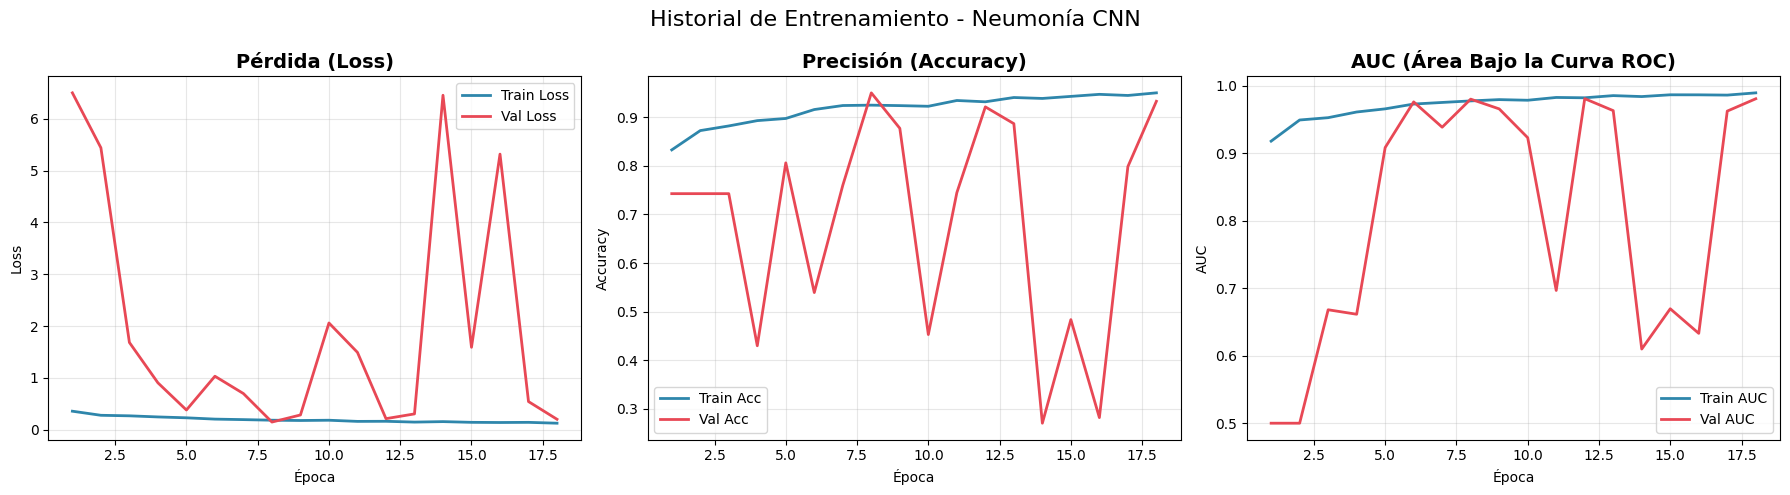

In [16]:
# ============================================================
# VISUALIZACIÓN DE CURVAS DE ENTRENAMIENTO
# ============================================================

def plot_training_history(history):
    """
    Grafica las métricas de entrenamiento y validación.
    Extendido del análisis básico de perrosygatos.ipynb.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history.history['loss']) + 1)
    
    # --- Pérdida ---
    axes[0].plot(epochs_range, history.history['loss'],
                 label='Train Loss', color='#2E86AB', linewidth=2)
    axes[0].plot(epochs_range, history.history['val_loss'],
                 label='Val Loss', color='#E84855', linewidth=2)
    axes[0].set_title('Pérdida (Loss)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- Accuracy ---
    axes[1].plot(epochs_range, history.history['accuracy'],
                 label='Train Acc', color='#2E86AB', linewidth=2)
    axes[1].plot(epochs_range, history.history['val_accuracy'],
                 label='Val Acc', color='#E84855', linewidth=2)
    axes[1].set_title('Precisión (Accuracy)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # --- AUC ---
    if 'auc' in history.history:
        axes[2].plot(epochs_range, history.history['auc'],
                     label='Train AUC', color='#2E86AB', linewidth=2)
        axes[2].plot(epochs_range, history.history['val_auc'],
                     label='Val AUC', color='#E84855', linewidth=2)
        axes[2].set_title('AUC (Área Bajo la Curva ROC)', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Época')
        axes[2].set_ylabel('AUC')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Historial de Entrenamiento - Neumonía CNN', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# 🎯 PASO 12: Evaluación en el Conjunto de Test

## ¿Por qué evaluar en test?

El conjunto de **test** es el conjunto que el modelo NUNCA ha visto durante el entrenamiento ni la validación. Es la medida real de la capacidad de generalización.

## Métricas de evaluación

### Matriz de Confusión
```
                 Predicho
              NORMAL  PNEUMONIA
Real NORMAL    [TN]     [FP]
     PNEUMONIA [FN]     [TP]
```

- **TN**: Verdadero Negativo (NORMAL bien clasificado)
- **TP**: Verdadero Positivo (PNEUMONIA bien clasificada)
- **FP**: Falso Positivo (NORMAL clasificado como PNEUMONIA) 
- **FN**: Falso Negativo (PNEUMONIA clasificada como NORMAL) ← ¡PELIGROSO!

### Fórmulas importantes
$$\text{Sensibilidad (Recall)} = \frac{TP}{TP + FN}$$
$$\text{Especificidad} = \frac{TN}{TN + FP}$$
$$\text{Precisión} = \frac{TP}{TP + FP}$$
$$\text{F1-Score} = \frac{2 \cdot Precisión \cdot Recall}{Precisión + Recall}$$

Evaluando en conjunto de test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.8638 - auc: 0.9283 - loss: 0.4840

RESULTADOS EN CONJUNTO DE TEST
  loss: 0.4840
  compile_metrics: 0.8638
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step


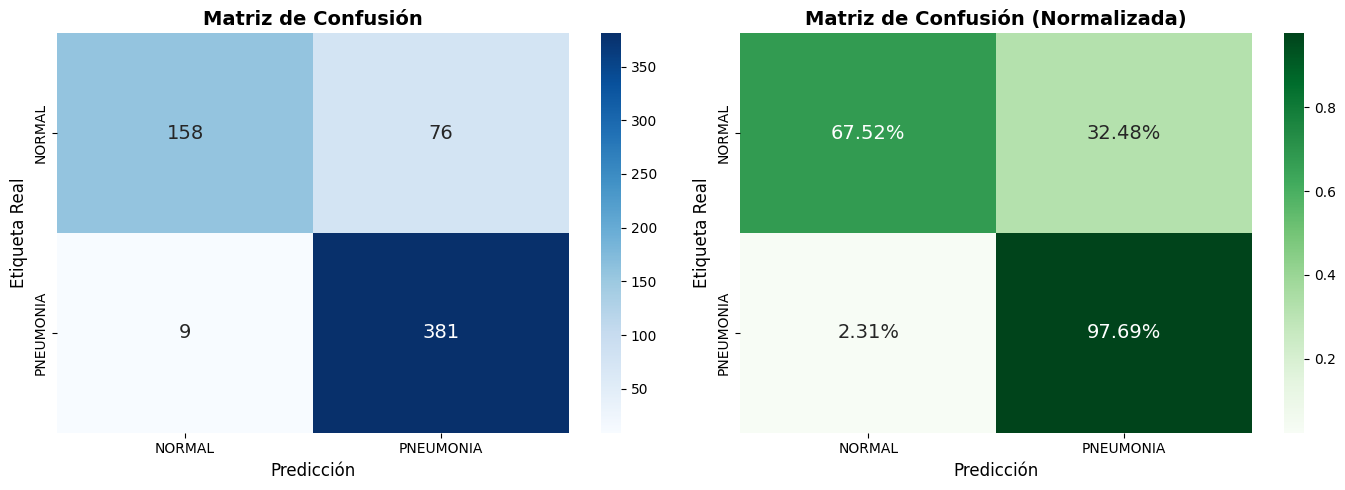


REPORTE DE CLASIFICACIÓN COMPLETO
              precision    recall  f1-score   support

      NORMAL       0.95      0.68      0.79       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.83      0.84       624
weighted avg       0.88      0.86      0.86       624


MÉTRICAS MÉDICAS CLAVE
  Verdaderos Positivos  (TP): 381  ← PNEUMONIA bien detectada
  Verdaderos Negativos  (TN): 158  ← NORMAL bien clasificada
  Falsos Positivos      (FP): 76  ← NORMAL mal clasificada como PNEUMONIA
  Falsos Negativos      (FN): 9  ← PNEUMONIA no detectada ⚠️

  Sensibilidad (Recall):  97.69%  (% de enfermos detectados)
  Especificidad:          67.52%  (% de sanos bien clasificados)
  Precisión:              83.37%  (% de pos. predichos que son reales)


In [17]:
# ============================================================
# EVALUACIÓN EN TEST
# ============================================================

print('Evaluando en conjunto de test...')
test_generator.reset()
test_results = model.evaluate(test_generator, verbose=1)

print('\n' + '='*50)
print('RESULTADOS EN CONJUNTO DE TEST')
print('='*50)
for metric_name, value in zip(model.metrics_names, test_results):
    print(f'  {metric_name}: {value:.4f}')

# ============================================================
# PREDICCIONES Y MATRIZ DE CONFUSIÓN
# ============================================================

# Obtener predicciones
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de la matriz de confusión
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], annot_kws={'size': 14}
)
axes[0].set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Etiqueta Real', fontsize=12)
axes[0].set_xlabel('Predicción', fontsize=12)

# Matriz de confusión normalizada
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], annot_kws={'size': 14}
)
axes[1].set_title('Matriz de Confusión (Normalizada)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Etiqueta Real', fontsize=12)
axes[1].set_xlabel('Predicción', fontsize=12)

plt.tight_layout()
plt.show()

# Reporte detallado
print('\n' + '='*60)
print('REPORTE DE CLASIFICACIÓN COMPLETO')
print('='*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Métricas médicamente relevantes
tn, fp, fn, tp = cm.ravel()
sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision     = tp / (tp + fp) if (tp + fp) > 0 else 0

print('\n' + '='*50)
print('MÉTRICAS MÉDICAS CLAVE')
print('='*50)
print(f'  Verdaderos Positivos  (TP): {tp}  ← PNEUMONIA bien detectada')
print(f'  Verdaderos Negativos  (TN): {tn}  ← NORMAL bien clasificada')
print(f'  Falsos Positivos      (FP): {fp}  ← NORMAL mal clasificada como PNEUMONIA')
print(f'  Falsos Negativos      (FN): {fn}  ← PNEUMONIA no detectada ⚠️')
print()
print(f'  Sensibilidad (Recall):  {sensibilidad:.2%}  (% de enfermos detectados)')
print(f'  Especificidad:          {especificidad:.2%}  (% de sanos bien clasificados)')
print(f'  Precisión:              {precision:.2%}  (% de pos. predichos que son reales)')

# 🔍 PASO 13: Predicciones sobre Imágenes Individuales

## Función de predicción

Similar a la función `plot_data()` del notebook de referencia, aquí visualizamos imágenes individuales con la predicción del modelo.

C:\Users\Rago\AppData\Local\Temp\ipykernel_26348\1518499920.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rago\AppData\Local\Temp\ipykernel_26348\1518499920.py:59: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


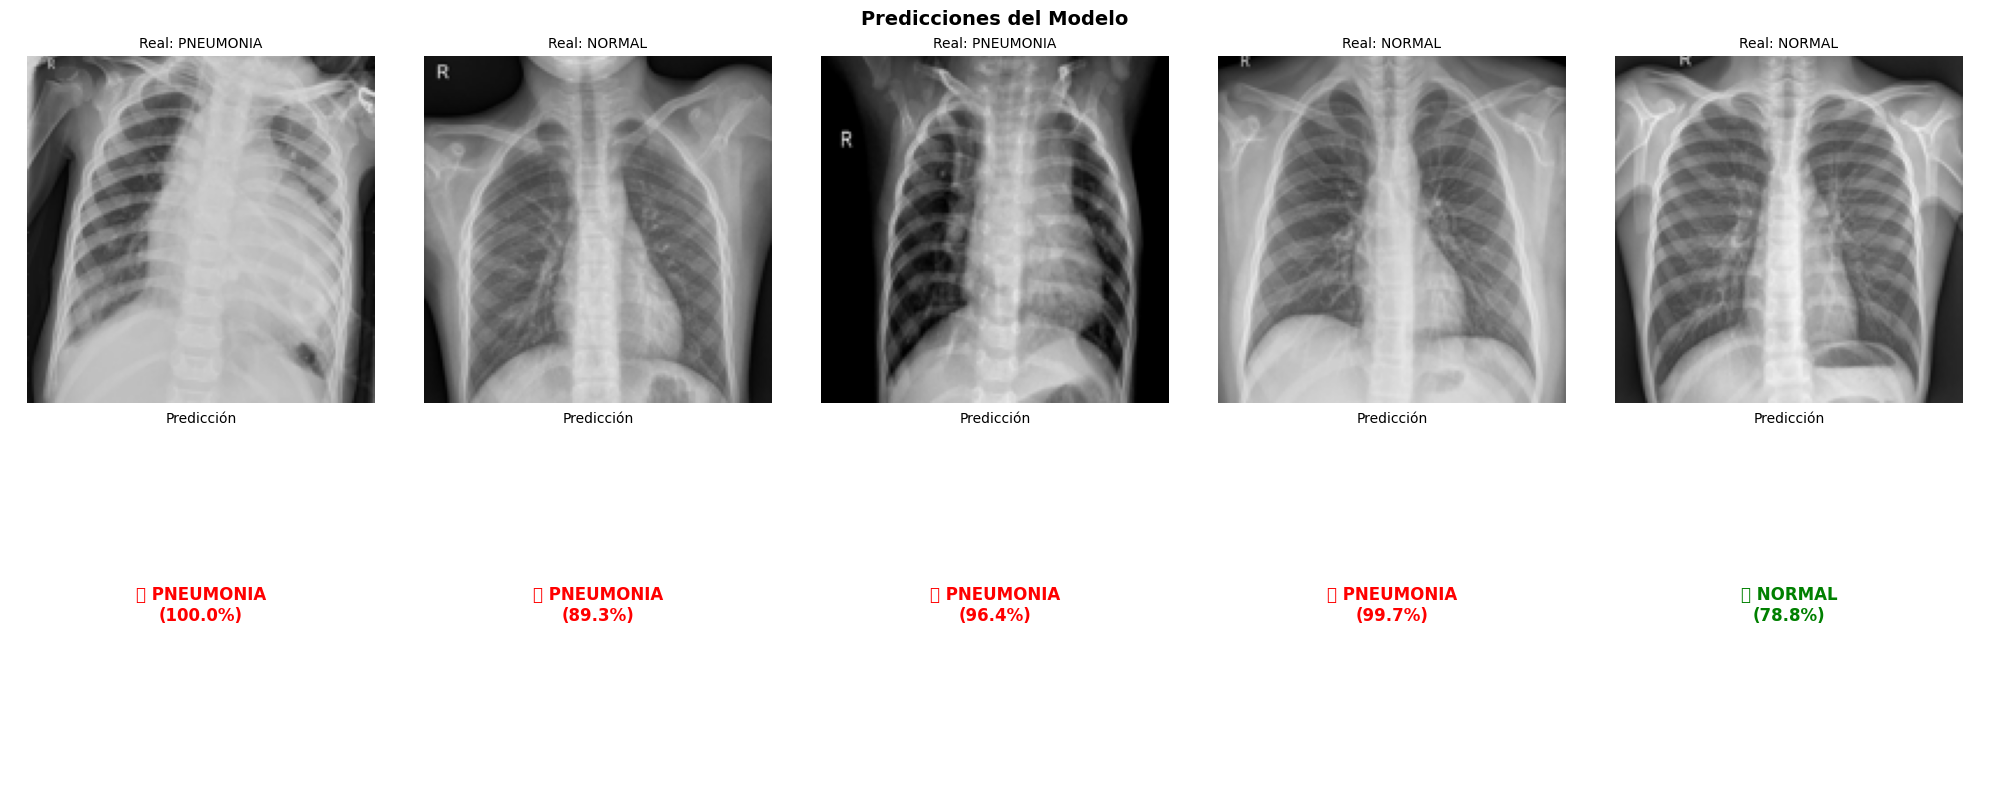

In [18]:
# ============================================================
# PREDICCIONES INDIVIDUALES
# ============================================================

def predict_and_plot(model, image_paths, class_names, img_size=(150, 150)):
    """
    Predice y visualiza imágenes individuales.
    Equivalente a plot_data() de perrosygatos.ipynb aplicado sobre test.
    
    Parámetros:
    -----------
    model : tf.keras.Model
        Modelo entrenado
    image_paths : list
        Lista de rutas a imágenes
    class_names : list
        Nombres de clases en orden de índice
    img_size : tuple
        Dimensiones de entrada del modelo
    """
    n = len(image_paths)
    fig, axes = plt.subplots(2, min(n, 5), figsize=(4*min(n, 5), 8))
    if n == 1:
        axes = [[axes[0]], [axes[1]]]
    
    for i, img_path in enumerate(image_paths[:5]):
        # Cargar y preprocesar
        img = Image.open(img_path).convert('RGB').resize(img_size)
        img_array = np.array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        
        # Predicción
        prob = model.predict(img_batch, verbose=0)[0][0]
        pred_class = class_names[1 if prob > 0.5 else 0]
        confidence = prob if prob > 0.5 else 1 - prob
        
        # Obtener etiqueta real del path
        real_class = 'NORMAL' if 'NORMAL' in img_path.upper() else 'PNEUMONIA'
        correct = '✅' if pred_class == real_class else '❌'
        
        # Imagen original
        col_ax = axes[0][i] if n > 1 else axes[0][0]
        col_ax.imshow(np.array(img), cmap='gray')
        col_ax.set_title(f'Real: {real_class}', fontsize=10)
        col_ax.axis('off')
        
        # Predicción
        pred_ax = axes[1][i] if n > 1 else axes[1][0]
        color = 'green' if pred_class == 'NORMAL' else 'red'
        pred_ax.text(0.5, 0.5,
                     f'{correct} {pred_class}\n({confidence:.1%})',
                     ha='center', va='center', fontsize=12,
                     color=color, fontweight='bold',
                     transform=pred_ax.transAxes)
        pred_ax.set_title('Predicción', fontsize=10)
        pred_ax.axis('off')
    
    plt.suptitle('Predicciones del Modelo', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Seleccionar imágenes de test para visualizar
test_normal_dir    = os.path.join(TEST_DIR, 'NORMAL')
test_pneumonia_dir = os.path.join(TEST_DIR, 'PNEUMONIA')

sample_normals    = [
    os.path.join(test_normal_dir, f)
    for f in random.sample(os.listdir(test_normal_dir)[:20], 3)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]
sample_pneumonias = [
    os.path.join(test_pneumonia_dir, f)
    for f in random.sample(os.listdir(test_pneumonia_dir)[:20], 2)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

all_samples = sample_normals + sample_pneumonias
random.shuffle(all_samples)

predict_and_plot(model, all_samples, CLASS_NAMES)

# 💾 PASO 14: Guardar el Modelo

## ¿Por qué guardar el modelo?

Guardar el modelo entrenado permite:
1. **Reutilizarlo** sin re-entrenar
2. **Compartirlo** con otros
3. **Desplegarlo** en producción

## Formatos de guardado

- **SavedModel (.keras / .h5)**: Formato completo que incluye arquitectura + pesos
- **Pesos solos**: Solo guarda los parámetros aprendidos
- **ONNX**: Formato portable para despliegue en diferentes frameworks

In [19]:
# ============================================================
# GUARDAR EL MODELO ENTRENADO
# ============================================================

MODEL_SAVE_PATH = 'pneumonia_cnn_model.keras'

# Guardar modelo completo (arquitectura + pesos + optimizador)
model.save(MODEL_SAVE_PATH)
print(f'✅ Modelo guardado en: {MODEL_SAVE_PATH}')

# Verificar que se puede cargar
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f'✅ Modelo cargado correctamente')
print(f'   Parámetros: {loaded_model.count_params():,}')

# Guardar también el historial de entrenamiento
import json
history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)
print('✅ Historial guardado en: training_history.json')

✅ Modelo guardado en: pneumonia_cnn_model.keras
✅ Modelo cargado correctamente
   Parámetros: 1,278,017
✅ Historial guardado en: training_history.json


# 📚 PASO 15: Resumen y Conclusiones

## Comparativa completa con perrosygatos.ipynb

| Aspecto | perrosygatos.ipynb | Este Notebook (Neumonía) |
|---------|-------------------|-------------------------|
| **Dataset** | Kaggle Dogs vs Cats | Kaggle Chest X-Ray Pneumonia |
| **Clases** | Cat (0) / Dog (1) | NORMAL (0) / PNEUMONIA (1) |
| **Tipo** | Clasificación binaria | Clasificación binaria |
| **split_data()** | Manual (90/5/5) | Dataset pre-dividido + función adaptada |
| **Generadores** | `ImageDataGenerator(rescale=1./255)` | `ImageDataGenerator` + augmentation |
| **target_size** | (150, 150) | (150, 150) |
| **batch_size** | 64 | 32 |
| **class_mode** | 'binary' | 'binary' |
| **Arquitectura** | Conv2D + ResBlocks + Dense | Conv2D + ResBlocks + Dense |
| **Capas Conv** | 3-4 bloques | 4 bloques |
| **Pérdida** | binary_crossentropy | binary_crossentropy |
| **Optimizador** | Adam | Adam |
| **Callbacks** | LearningRateScheduler | LR Scheduler + EarlyStopping + ReduceLR |
| **plot_data** | `plot_data(generator)` | `plot_sample_images()` + `predict_and_plot()` |
| **Métricas** | Accuracy | Accuracy + AUC + Sensibilidad + Especificidad |

---

## 🧠 Conceptos clave para sustentar ante el profesor

### 1. ¿Por qué una CNN para imágenes médicas?
Las CNNs aprenden **filtros jerárquicos**: bordes → texturas → formas → estructuras complejas. En radiografías, detectan patrones de inflamación, opacificación o consolidación pulmonar.

### 2. ¿Qué hace `rescale=1./255`?
Normaliza los valores de píxeles de [0, 255] a [0, 1]. Esto:
- Acelera la convergencia del gradiente
- Evita saturación en las activaciones

### 3. ¿Por qué Data Augmentation?
Crea variaciones artificiales para:
1. Aumentar el tamaño efectivo del dataset
2. Reducir el overfitting
3. Hacer el modelo más robusto

### 4. ¿Qué es un Bloque Residual?
```
F(x) + x
```
La "conexión de salto" permite que el gradiente fluya sin degradarse, resolviendo el problema del **gradiente que desaparece** en redes profundas.

### 5. ¿Por qué class_weight?
El dataset tiene 3:1 (PNEUMONIA:NORMAL). Sin class_weight, el modelo puede predecir siempre PNEUMONIA y obtener >75% de accuracy sin aprender nada útil.

### 6. ¿Por qué GlobalAveragePooling y no Flatten?
GAP reduce cada feature map a un valor promedio, siendo más robusto a variaciones espaciales y con menos parámetros que Flatten.

### 7. ¿Por qué sigmoide en la salida y no softmax?
Con 2 clases en clasificación binaria, una sola neurona con sigmoide es equivalente a dos neuronas con softmax. Es más eficiente.

### 8. ¿Qué significa AUC > 0.9?
El modelo tiene un 90%+ de probabilidad de rankear una imagen de PNEUMONIA con mayor score que una imagen NORMAL. Es una métrica robusta al desbalance.

---

## 📊 Posibles preguntas del profesor y respuestas

**P: ¿Cómo funciona ImageDataGenerator.flow_from_directory?**  
R: Lee imágenes del disco, las redimensiona al `target_size`, las normaliza y las agrupa en batches. Asigna etiquetas automáticamente según el nombre de la subcarpeta.

**P: ¿Qué diferencia hay entre train, val y test?**  
R: Train: para ajustar pesos. Val: para seleccionar hiperparámetros y detectar overfitting. Test: para medir rendimiento real, ¡no debe tocarse hasta el final!

**P: ¿Por qué batch_size importa?**  
R: Batches pequeños → gradiente más ruidoso pero mejor generalización. Batches grandes → entrenamiento más estable pero puede sobreajustar. 32-64 es el rango típico.

**P: ¿Qué hace BatchNormalization?**  
R: Normaliza las activaciones de una capa para que tengan media≈0 y varianza≈1. Reduce la sensibilidad a la inicialización y permite tasas de aprendizaje más altas.

In [20]:
# ============================================================
# RESUMEN FINAL DE RESULTADOS
# ============================================================

print('='*60)
print('RESUMEN FINAL DEL PROYECTO')
print('Clasificación de Neumonía - Easter Week')
print('='*60)

print(f'\n📊 Dataset:')
print(f'   Train: {sum(train_counts_final.values())} imágenes')
print(f'   Val:   {sum(val_counts_final.values())} imágenes')
print(f'   Test:  {sum(test_counts_final.values())} imágenes')

print(f'\n🧠 Modelo:')
print(f'   Arquitectura: CNN con bloques residuales')
print(f'   Parámetros: {model.count_params():,}')
print(f'   Épocas entrenadas: {len(history.history["loss"])}')

print(f'\n📈 Métricas finales (conjunto TEST):')
for name, val in zip(model.metrics_names, test_results):
    print(f'   {name}: {val:.4f}')

print(f'\n💡 Basado en la misma lógica de: perrosygatos.ipynb')
print(f'   Dataset: Kaggle Chest X-Ray Pneumonia')
print(f'   https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia')
print('='*60)

RESUMEN FINAL DEL PROYECTO
Clasificación de Neumonía - Easter Week

📊 Dataset:
   Train: 5216 imágenes
   Val:   521 imágenes
   Test:  624 imágenes

🧠 Modelo:
   Arquitectura: CNN con bloques residuales
   Parámetros: 1,278,017
   Épocas entrenadas: 18

📈 Métricas finales (conjunto TEST):
   loss: 0.4840
   compile_metrics: 0.8638

💡 Basado en la misma lógica de: perrosygatos.ipynb
   Dataset: Kaggle Chest X-Ray Pneumonia
   https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
